# Install required libraries

In [1]:
!pip install pandas numpy openpyxl scipy matplotlib seaborn plotly scikit-learn statsmodels xgboost lightgbm shap pulp sqlalchemy requests pandera

  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
  Using cached pulp-3.3.2-py3-none-any.whl.metadata (8.6 kB)
  Using cached pandera-0.33.1-py3-none-any.whl.metadata (11 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB 1.6 MB/s eta 0:00:00
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached typeguard-4.6.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached typing_inspect-0.9.0-py3-none-any.whl.metadata (1.5 kB)
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
Using cached lightgbm-4.7.0-py3-none-win_amd64.whl (1.4 MB)
   -------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.17.0 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.


In [2]:
pip install prophet fastapi uvicorn ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


# Import libraries

In [5]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from scipy.optimize import linprog

from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from sklearn.ensemble import(
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Load the dataset

In [7]:
file_path = "Online_Retail.csv"

df = pd.read_csv(
    file_path,
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string"
    },
    low_memory=False
)

print("Dataset loaded successfully")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully
Rows: 541909
Columns: 8


# Display the dataset

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [10]:
df.sample(10, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom
465024,576200,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-11-14 12:14:00,2.95,15572.0,United Kingdom
477777,577076,22614,PACK OF 12 SPACEBOY TISSUES,12,2011-11-17 15:08:00,0.39,14362.0,United Kingdom
367855,568909,22596,CHRISTMAS STAR WISH LIST CHALKBOARD,12,2011-09-29 13:38:00,1.25,16818.0,United Kingdom
491657,578072,21109,LARGE CAKE TOWEL CHOCOLATE SPOTS,1,2011-11-22 16:02:00,6.75,17759.0,United Kingdom
269641,560491,23297,SET 40 HEART SHAPE PETIT FOUR CASES,2,2011-07-19 10:51:00,1.65,12415.0,Australia


# WEEK 1 - Strategic baseline

In [11]:
print("WEEK 1 - STRATEGIC BASELINE")
print("=" * 50)

print("Rows:", len(df))
print("Columns:", df.shape[1])

print("Unique invoices:", df["InvoiceNo"].nunique())
print("Unique customers:", df["CustomerID"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Countries:", df["Country"].nunique())

WEEK 1 - STRATEGIC BASELINE
Rows: 541909
Columns: 8
Unique invoices: 25900
Unique customers: 4372
Unique products: 4070
Countries: 38


# Prepare basic data types

In [13]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["UnitPrice"] = pd.to_numeric(
    df["UnitPrice"],
    errors="coerce"
)

df["Revenue"] = (
    df["Quantity"] *
    df["UnitPrice"]
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  string        
 1   StockCode    541909 non-null  string        
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
 8   Revenue      541909 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(2), string(2)
memory usage: 37.2 MB


# Week 1 business KPIs

In [17]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()
total_countries = df["Country"].nunique()

average_order_value = (
    total_revenue / 
    total_orders
)

total_units = df["Quantity"].sum()

week1_kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Countries",
        "Total Units Sold",
        "Average Order Value"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        total_products,
        total_countries,
        total_units,
        average_order_value
    ]
})

week1_kpis

,Metric,Value
0,Total Revenue,9.747748e+06
1,Total Orders,2.590000e+04
2,Total Customers,4.372000e+03
3,Total Products,4.070000e+03
4,Total Countries,3.800000e+01
5,Total Units Sold,5.176450e+06
6,Average Order Value,3.763609e+02


# Week 1 monthly revenue

In [18]:
monthly_revenue = (
    df.assign(
        Month=df["InvoiceDate"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby("Month")["Revenue"]
    .sum()
)

monthly_revenue

Month
2010-12     748957.020
2011-01     560000.260
2011-02     498062.650
2011-03     683267.080
2011-04     493207.121
2011-05     723333.510
2011-06     691123.120
2011-07     681300.111
2011-08     682680.510
2011-09    1019687.622
2011-10    1070704.670
2011-11    1461756.250
2011-12     433668.010
Name: Revenue, dtype: float64

# Plot monthly revenue

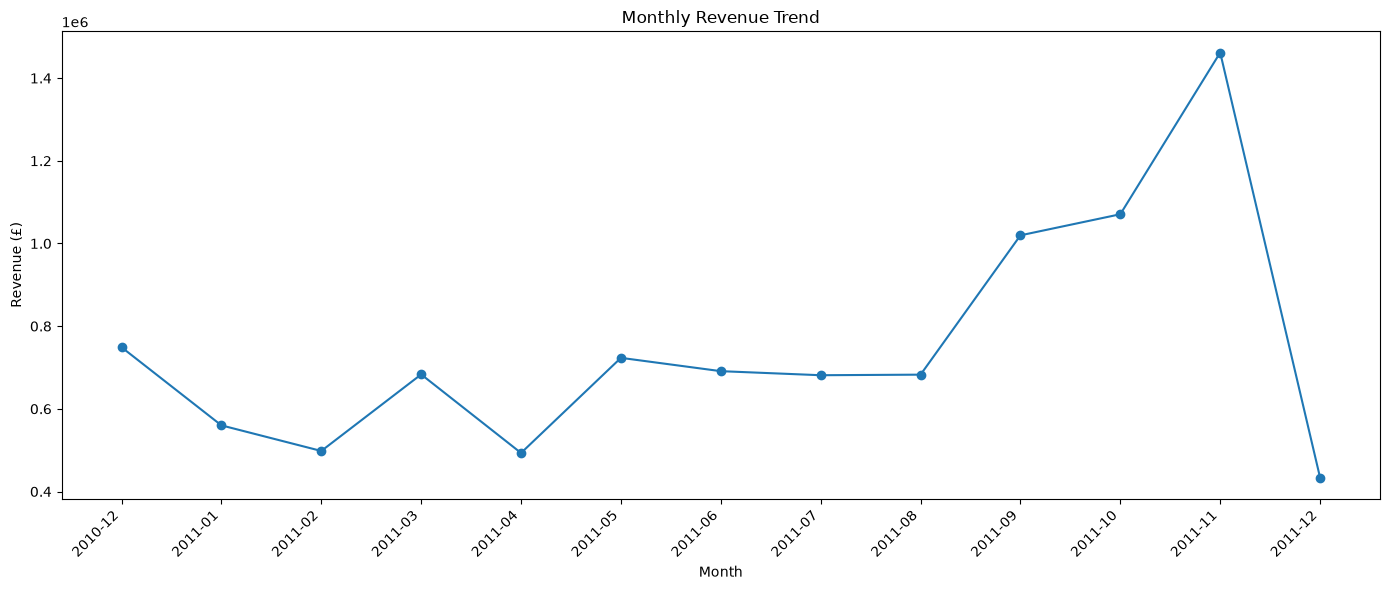

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

# Week 1 strategic Horizon 3 timeline

In [22]:
horizon3 = pd.DataFrame({
     "Period": [
        "Months 10–12",
        "Months 13–15",
        "Months 16–18"
    ],
    "Initiative": [
        "Optimization Pilot",
        "Scenario Planning and Expansion",
        "Analytics Center of Excellence"
    ],
    "Decision_Gate": [
        "Evaluate pilot performance",
        "Scale only if measurable improvement is demonstrated",
        "Institutionalize governance, reusable models and monitoring"
    ]
})

horizon3

,Period,Initiative,Decision_Gate
0,Months 10–12,Optimization Pilot,Evaluate pilot performance
1,Months 13–15,Scenario Planning and Expansion,Scale only if measurable improvement is demons...
2,Months 16–18,Analytics Center of Excellence,"Institutionalize governance, reusable models a..."


# Week 2 - DATA COLLECTION AND CLEANING

## Create a raw copy

In [23]:
raw = df.copy()

clean = raw.copy()

print(
    "Raw dataset shape:",
    clean.shape
)

Raw dataset shape: (541909, 9)


## Initial data profile

In [24]:
print("DATA TYPES")
print("=" * 50)

print(clean.dtypes)

DATA TYPES
InvoiceNo              string
StockCode              string
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
Revenue               float64
dtype: object


In [26]:
print("\nMISSING VALUES")
print("=" * 50)

print(clean.isnull().sum())


MISSING VALUES
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Revenue             0
dtype: int64


In [27]:
print("\nMISSING VALUE PERCENTAGE")
print("=" * 50)

missing_percentage = (
    clean.isnull().mean() * 100
).sort_values(ascending=False)

print(missing_percentage)


MISSING VALUE PERCENTAGE
CustomerID     24.926694
Description     0.268311
InvoiceNo       0.000000
Quantity        0.000000
StockCode       0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
Revenue         0.000000
dtype: float64


## Duplicate analysis

In [28]:
duplicate_count = clean.duplicated().sum()

print(
    "Exact duplicate rows:",
    duplicate_count
)

Exact duplicate rows: 5268


## Negative quantities

In [29]:
negative_quantity_count = (
    clean["Quantity"] < 0
).sum()

print(
    "Negative quantity rows:",
    negative_quantity_count
)

Negative quantity rows: 10624


## Invalid UnitPrice

In [30]:
invalid_price_count = (
    clean["UnitPrice"] <= 0
).sum()

print(
    "UnitPrice <= 0:",
    invalid_price_count
)

UnitPrice <= 0: 2517


## Cancellation analysis

In [32]:
clean["IsCancellation"] = (
    clean["InvoiceNo"]
    .astype(str)
    .str.upper()
    .str.startswith("C")
)

print(
    clean["IsCancellation"]
    .value_counts()
)

IsCancellation
False    532621
True       9288
Name: count, dtype: int64


## Standardize columns

In [34]:
clean.columns = (
    clean.columns
    .str.strip()
)

clean["Description"] = (
    clean["Description"]
    .astype("string")
    .str.strip()
)

clean["Country"] = (
    clean["Country"]
    .astype("string")
    .str.strip()
)

clean["InvoiceNo"] = (
    clean["InvoiceNo"]
    .astype("string")
)

clean["StockCode"] = (
    clean["StockCode"]
    .astype("string")
)

clean["InvoiceDate"] = pd.to_datetime(
    clean["InvoiceDate"],
    errors="coerce"
)

clean["Quantity"] = pd.to_numeric(
    clean["Quantity"],
    errors="coerce"
)

clean["UnitPrice"] = pd.to_numeric(
    clean["UnitPrice"],
    errors="coerce"
)

## Remove duplicates

In [35]:
duplicates_before = (
    clean.duplicated().sum()
)

clean = clean.drop_duplicates()

duplicates_after = (
    clean.duplicated().sum()
)

print(
    "Duplicates before:",
    duplicates_before
)
print(
    "Duplicates after:",
    duplicates_after
)

Duplicates before: 5268
Duplicates after: 0


## Handle missing Description

In [36]:
missing_description_before = (
    clean["Description"].isna().sum()
)

clean = clean.dropna(
    subset=["Description"]
)

missing_description_after = (
    clean["Description"].isna().sum()
)

print(
    "Missing Description before:",
    missing_description_before
)

print(
    "Missing Description after:",
    missing_description_after
)

Missing Description before: 1454
Missing Description after: 0


## Handle CustomerID

In [37]:
clean["CustomerID_was_missing"] = (
    clean["CustomerID"].isna()
)

clean["CustomerID"] = (
    clean["CustomerID"]
    .astype("string")
    .fillna("GUEST")
)

### Calculate the percentage

In [38]:
guest_percentage = (
    clean["CustomerID"]
    .eq("GUEST")
    .mean()
    * 100
)

print(
    f"Guest customer percentage: "
    f"{guest_percentage:.2f}%"
)

Guest customer percentage: 24.96%


## Seperate cancellations

In [39]:
clean["IsCancellation"] = (
    clean["InvoiceNo"]
    .str.upper()
    .str.startswith("C", na=False)
)

returns = clean[
    clean["IsCancellation"]
].copy()

sales = clean[
    ~clean["IsCancellation"]
].copy()

print(
    "Sales rows:",
    len(sales)
)

print(
    "Cancellation/return rows:",
    len(returns)
)

Sales rows: 525936
Cancellation/return rows: 9251


## Remove invalid prices from sales

In [40]:
invalid_sales_prices = (
    sales["UnitPrice"] <= 0
).sum()

print(
    "Invalid sales prices before:",
    invalid_sales_prices
)

sales = sales[
    sales["UnitPrice"] > 0
].copy()

print(
    "Invalid prices after:",
    (sales["UnitPrice"] <= 0).sum()
)

Invalid sales prices before: 1058
Invalid prices after: 0


## Create Revenue

In [42]:
sales["Revenue"] = (
    sales["Quantity"] *
    sales["UnitPrice"]
)

returns["Revenue"] = (
    returns["Quantity"] *
    returns["UnitPrice"]
)

sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancellation,CustomerID_was_missing
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False


## IQR outlier detection

In [44]:
Q1 = sales["UnitPrice"].quantile(0.25)
Q3 = sales["UnitPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = (
    Q1 - 1.5 * IQR
)

upper_bound = (
    Q3 + 1.5 * IQR
)

sales["Price_Outlier"] = (
    ~sales["UnitPrice"]
    .between(
        lower_bound,
        upper_bound
    )
)

print(
    "Lower bound:",
    lower_bound
)

print(
    "Outliers flagged:",
    sales["Price_Outlier"].sum()
)

Lower bound: -3.0700000000000003
Outliers flagged: 37827


## Week 2 final validation

In [45]:
print("FINAL DATA QUALITY CHECK")
print("=" * 60)

print(
    "sales rows:",
    len(sales)
)

print(
    "Duplicate rows:",
    sales.duplicated().sum()
)

print(
    "Missing Description:",
    sales["CustomerID"].isna().sum()
)

print(
    "Invalid UnitPrice:",
    (sales["UnitPrice"] <= 0).sum()
)

print(
    "Guest customer percentage:",
    sales["CustomerID"]
    .eq("GUEST")
    .mean() * 100
)

FINAL DATA QUALITY CHECK
sales rows: 524878
Duplicate rows: 0
Missing Description: 0
Invalid UnitPrice: 0
Guest customer percentage: 25.184138028265618


## Week 2 before/after table

In [46]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Raw Rows",
        "Duplicate Rows",
        "Missing Description",
        "Missing CustomerID",
        "Negative Quantity",
        "UnitPrice <= 0",
        "Cancellation Rows",
        "Clean Sales Rows"
    ],

    "Value": [
        len(raw),
        raw.duplicated().sum(),
        raw["Description"].isna().sum(),
        raw["CustomerID"].isna().sum(),
        (raw["Quantity"] < 0).sum(),
        (raw["UnitPrice"] <= 0).sum(),
        raw["InvoiceNo"]
        .astype(str)
        .str.startswith("C")
        .sum(),
        len(sales)
    ]
})

## Save cleaned data

In [47]:
os.makedirs(
    "outputs",
    exist_ok=True
)

sales.to_csv(
    "outputs/online_retail_sales_clean.csv",
    index=False
)

returns.to_csv(
    "outputs/online_retail_returns.csv",
    index=False
)

print("Clean datasets saved.")

Clean datasets saved.


# WEEK 3 - EXPLORATORY DATA ANALYSIS

## Load clean dataset

In [49]:
sales = pd.read_csv(
    "outputs/online_retail_sales_clean.csv",
    parse_dates=["InvoiceDate"]
)

sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancellation,CustomerID_was_missing,Price_Outlier
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False,False


## KPI dashboard data

In [50]:
revenue = sales["Revenue"].sum()
orders = sales["InvoiceNo"].nunique()
customers = sales["CustomerID"].nunique()
products = sales["StockCode"].nunique()
countries = sales["Country"].nunique()
units = sales["Quantity"].sum()

AOV = revenue / orders

eda_kpis = pd.DataFrame({
    "Metric": [
        "Revenue",
        "Orders",
        "Customers",
        "Products",
        "Countries",
        "Units",
        "Average Order Value"
    ],
    "Value": [
        revenue,
        orders,
        customers,
        products,
        countries,
        units,
        AOV
    ]
})

eda_kpis

,Metric,Value
0,Revenue,1.064211e+07
1,Orders,1.996200e+04
2,Customers,4.339000e+03
3,Products,3.922000e+03
4,Countries,3.800000e+01
5,Units,5.572420e+06
6,Average Order Value,5.331185e+02


## Monthly revenue

In [52]:
monthly = (
    sales
    .set_index("InvoiceDate")["Revenue"]
    .resample("ME")
    .sum()
)

monthly

InvoiceDate
2010-12-31     821452.730
2011-01-31     689811.610
2011-02-28     522545.560
2011-03-31     716215.260
2011-04-30     536968.491
2011-05-31     769296.610
2011-06-30     760547.010
2011-07-31     718076.121
2011-08-31     757841.380
2011-09-30    1056435.192
2011-10-31    1151263.730
2011-11-30    1503866.780
2011-12-31     637790.330
Freq: ME, Name: Revenue, dtype: float64

## Monthly revenue visualization

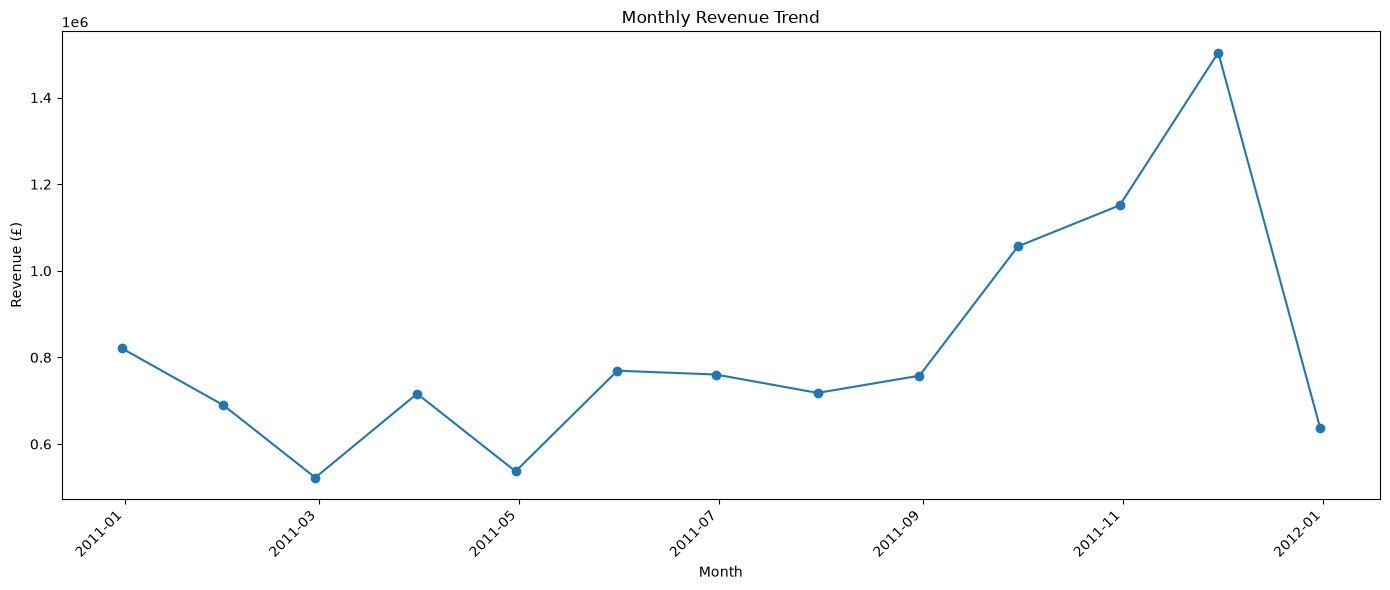

In [53]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.title(
    "Monthly Revenue Trend"
)

plt.xlabel("Month")

plt.ylabel("Revenue (£)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

## Top countries

In [54]:
country_revenue = (
    sales
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

## Top country chart

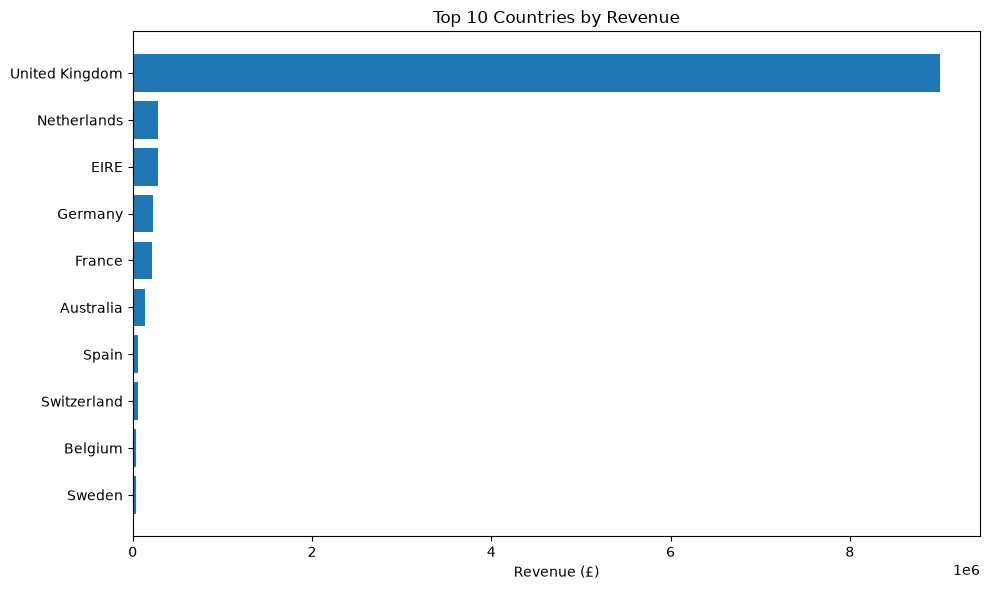

In [55]:
top_countries = (
    country_revenue
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10,6))

plt.barh(
    top_countries.index,
    top_countries.values
)

plt.title(
    "Top 10 Countries by Revenue"
)

plt.xlabel(
    "Revenue (£)"
)

plt.tight_layout()
plt.show()

## Top products

In [56]:
product_revenue = (
    sales
    .groupby(
        [
            "StockCode",
            "Description"
        ]
    )["Revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

product_revenue.head(20)

StockCode  Description                       
DOT        DOTCOM POSTAGE                        206248.77
22423      REGENCY CAKESTAND 3 TIER              174156.54
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER    104284.24
47566      PARTY BUNTING                          99445.23
85099B     JUMBO BAG RED RETROSPOT                94159.81
23166      MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POST       POSTAGE                                78101.88
M          Manual                                 77750.27
23084      RABBIT NIGHT LIGHT                     66870.03
22086      PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
84879      ASSORTED COLOUR BIRD ORNAMENT          58927.62
79321      CHILLI LIGHTS                          54096.36
23298      SPOTTY BUNTING                         42513.48
22386      JUMBO BAG PINK POLKADOT                42401.01
21137      BLACK RECORD COVER FRAME               40633.38
22502     

## Top products chart

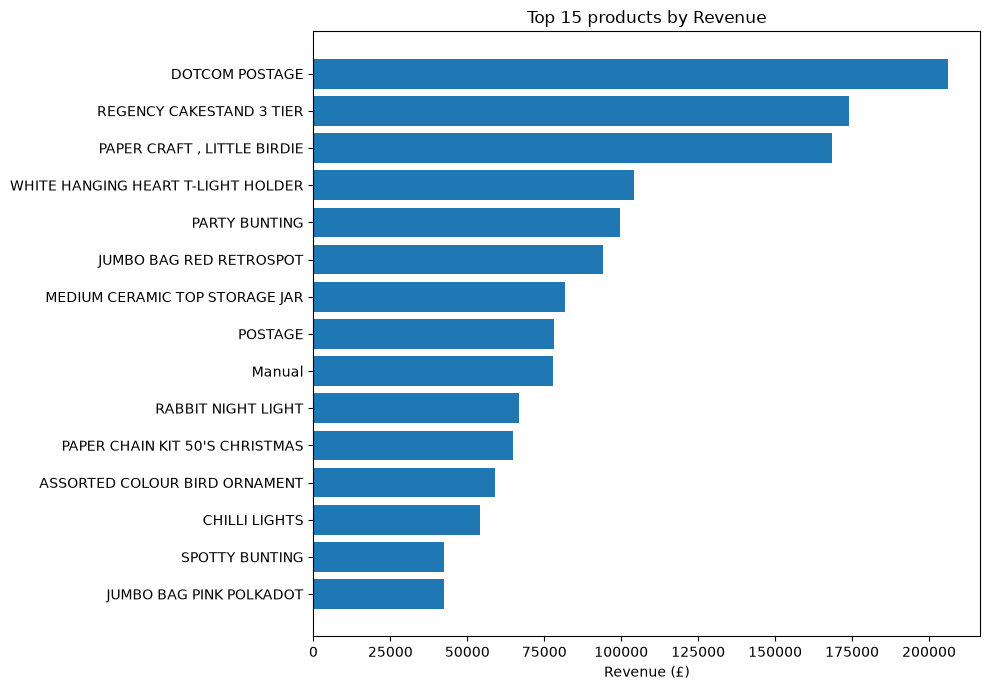

In [57]:
top_products = (
    product_revenue
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_products.index.get_level_values(
        "Description"
    ),
    top_products.values
)

plt.title(
    "Top 15 products by Revenue"
)

plt.xlabel(
    "Revenue (£)"
)

plt.tight_layout()
plt.show()

## Revenue distribution

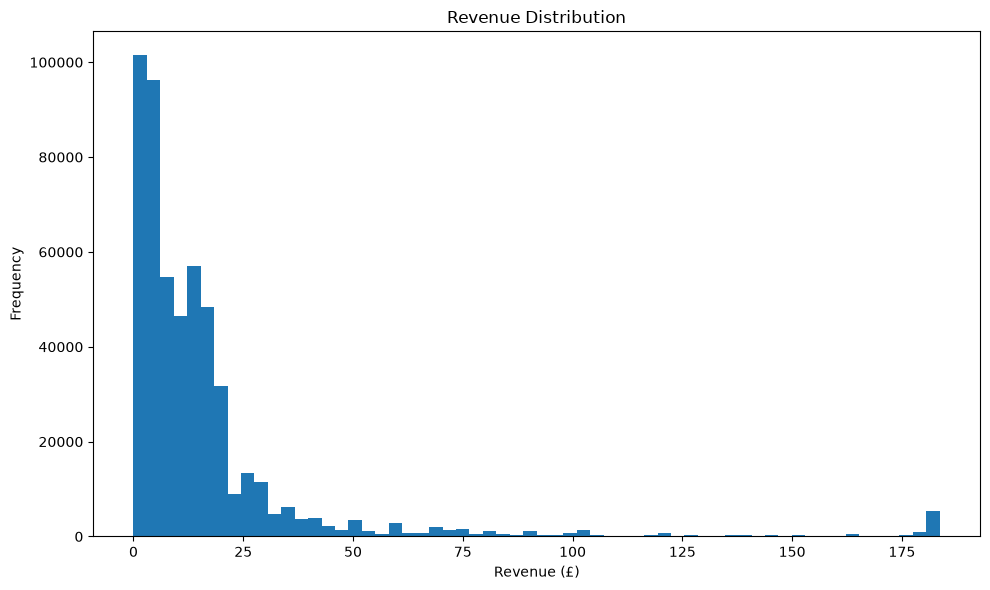

In [58]:
revenue_visual = (
    sales["Revenue"]
    .clip(
        upper=sales["Revenue"].quantile(0.99)
    )
)

plt.figure(figsize=(10, 6))

plt.hist(
    revenue_visual,
    bins=60
)

plt.title(
    "Revenue Distribution"
)

plt.xlabel(
    "Revenue (£)"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()

## Quantity boxplot

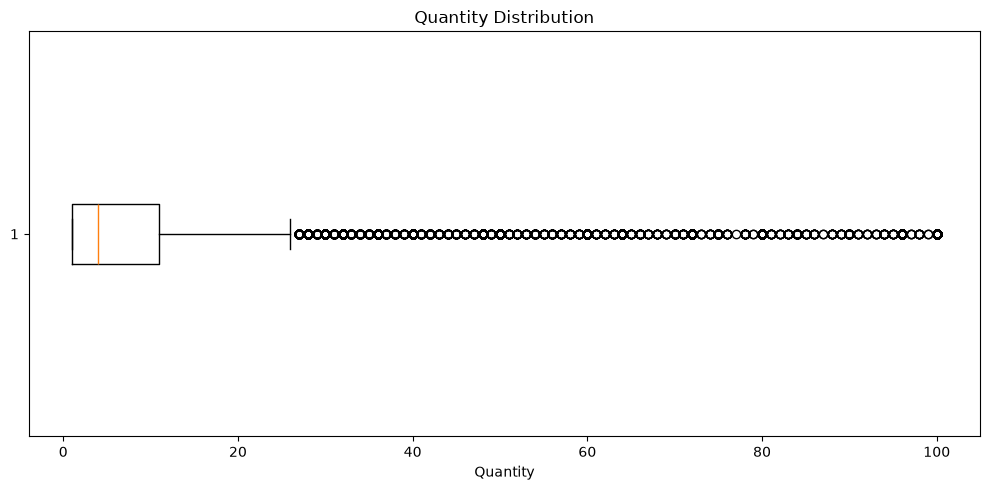

In [59]:
quantity_visual = (
    sales["Quantity"]
    .clip(
        upper=sales["Quantity"].quantile(0.99)
    )
)

plt.figure(figsize=(10, 5))

plt.boxplot(
    quantity_visual,
    vert=False
)

plt.title(
    "Quantity Distribution"
)

plt.xlabel(
    "Quantity"
)

plt.tight_layout()
plt.show()

## Quantity vs Unit Price

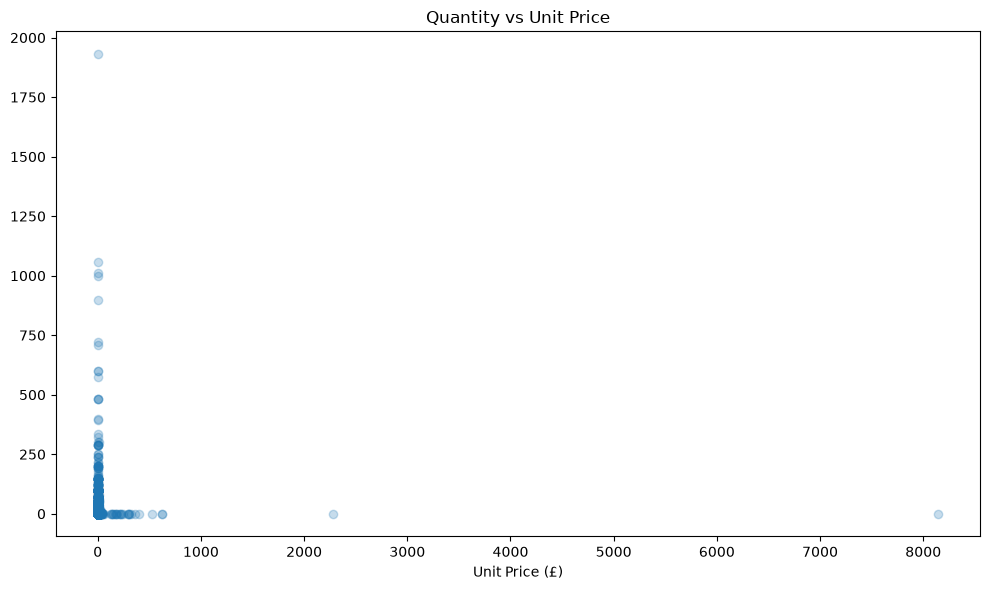

In [60]:
sample = sales[
    [
        "Quantity",
        "UnitPrice",
        "Revenue"
    ]
].sample(
    min(10000, len(sales)),
    random_state=42
)

plt.figure(figsize=(10, 6))

plt.scatter(
    sample["UnitPrice"],
    sample["Quantity"],
    alpha=0.25
)

plt.title(
    "Quantity vs Unit Price"
)

plt.xlabel(
    "Unit Price (£)"
)

plt.tight_layout()
plt.show()

## Correlation matrix

In [61]:
corr = sales[
    [
        "Quantity",
        "UnitPrice",
        "Revenue"
    ]
].corr()

corr

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Revenue,0.907402,0.137381,1.000000


## Correlation heatmap

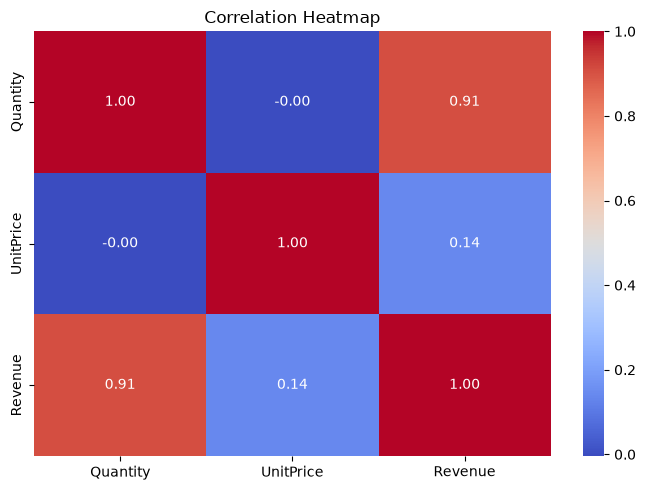

In [62]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.tight_layout()
plt.show()

## Day of week analysis

In [64]:
sales["DayOfWeek"] = (
    sales["InvoiceDate"]
    .dt.day_name()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_revenue = (
    sales
    .groupby("DayOfWeek")["Revenue"]
    .sum()
    .reindex(day_order)
)

day_revenue

DayOfWeek
Monday       1775782.071
Tuesday      2175700.511
Wednesday    1847074.380
Thursday     2199292.570
Friday       1837470.491
Saturday             NaN
Sunday        806790.781
Name: Revenue, dtype: float64

## Day-of-week chart

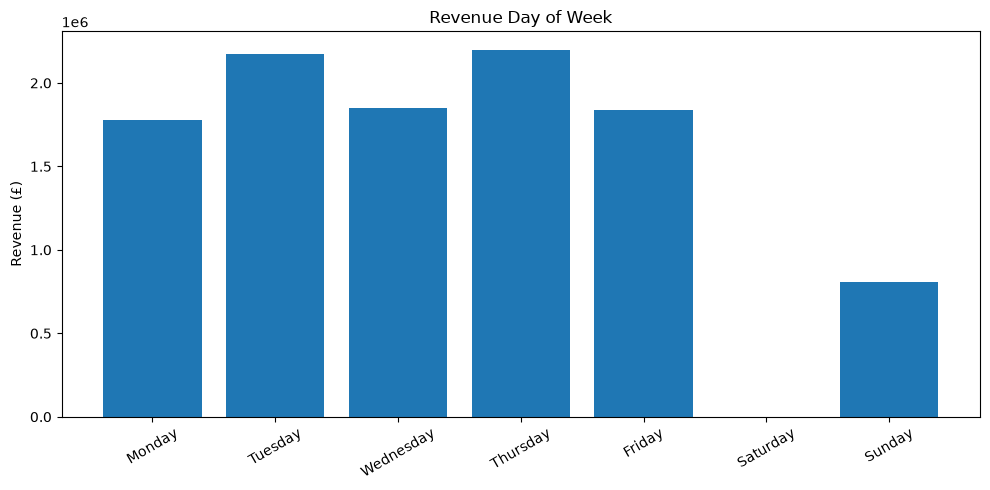

In [65]:
plt.figure(figsize=(10, 5))

plt.bar(
    day_revenue.index,
    day_revenue.values
)

plt.title(
    "Revenue Day of Week"
)

plt.ylabel(
    "Revenue (£)"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()

## Interactive Plotly visualization

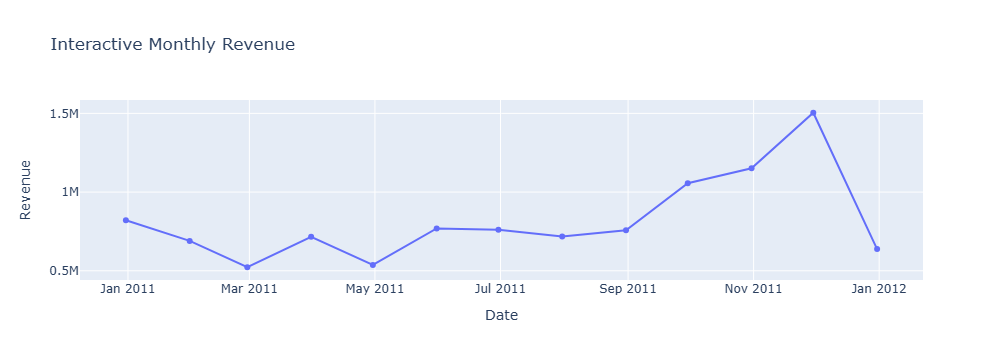

In [66]:
monthly_df = (
    monthly.reset_index()
)

monthly_df.columns = (
    "Date",
    "Revenue"
)

fig = px.line(
    monthly_df,
    x="Date",
    y="Revenue",
    markers=True,
    title="Interactive Monthly Revenue"
)

fig.show()

In [68]:
fig.write_html(
    "outputs/interactive_monthly_revenue.html"
)

print("Intercative chart saved.")

Intercative chart saved.


# WEEK 4 - PREDECTIVE ANALYSIS

## Create weekly dataset

In [70]:
weekly = (
    sales
    .set_index("InvoiceDate")["Revenue"]
    .resample("W")
    .sum()
    .to_frame("Revenue")
)

weekly.head()

,Revenue
InvoiceDate,
2010-12-05,184669.47
2010-12-12,329108.22
2010-12-19,215357.04
2010-12-26,92318.00
2011-01-02,0.00


## Create time features

In [82]:
weekly["WeekOfYear"] = (
    weekly.index
    .isocalendar()
    .week
    .astype(int)
)

weekly["Month"] = weekly.index.month

weekly["Quarter"] = weekly.index.quarter

weekly["Year"] = weekly.index.year

weekly ["Trend"] = np.arange(len(weekly))

## Lag features

In [83]:
for lag in [1,2,3,4,8,12]:
    weekly[f"lag_{lag}"] = weekly["Revenue"].shift(lag)

## Rolling features

In [84]:
for window in [4,8,12]:
    weekly[f"RollingMean_{window}"] = (
        weekly["Revenue"].shift(1).rolling(window).mean()
    )

## Remove rows created by lagging

In [85]:
weekly_model = weekly.dropna().copy()

print(weekly_model.shape)

(42, 15)


## Train/test split

In [86]:
train = weekly_model.iloc[:-8].copy()
test = weekly_model.iloc[-8:].copy()

print("Training rows:", len(train))
print("Test rows:", len(test))

Training rows: 34
Test rows: 8


## Define features

In [87]:
features = [
    column 
    for column in weekly_model.columns
    if column != "Revenue"       
]

X_train = train[features]
y_train = train["Revenue"]

X_test = test[features]
y_test = test["Revenue"]

## Baseline model

In [90]:
baseline_predictions = (test["RollingMean_4"].values)

print("Baseline predictions:")
print(baseline_predictions)

Baseline predictions:
[274215.6805  258634.74775 270601.18    265990.7575  301230.57
 329004.145   342954.5275  348643.4325 ]


## Baseline metrics

In [91]:
baseline_mae = (
    mean_absolute_error(
        y_test, baseline_predictions
    )
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test, baseline_predictions
    )
)

baseline_mape = (
    mean_absolute_percentage_error(
        y_test, baseline_predictions
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline MAPE:", baseline_mape)

Baseline MAE: 51235.52803125001
Baseline RMSE: 73758.56554935522
Baseline MAPE: 0.1277852513655931


## Random Foreset

In [95]:
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

rf_predictions = (
    rf.predict(X_test)
)

## Random Forest metrics

In [96]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_mape = mean_absolute_percentage_error(y_test, rf_predictions)

print("Random Forset MAE:", rf_mae)
print("Random Forset RMSE:", rf_rmse)
print("Random Forset MAPE:", rf_mape)

Random Forset MAE: 73145.41608437609
Random Forset RMSE: 101442.31144332027
Random Forset MAPE: 0.1848198860697834


## XGBoost

In [97]:
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_predictions = (xgb.predict(X_test))

## XGBoost metrics

In [99]:
xgb_mae = mean_absolute_error(
    y_test, xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test, xgb_predictions
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test, xgb_predictions
)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAPE:", xgb_mape)

XGBoost MAE: 78293.539609375
XGBoost RMSE: 113421.67381652197
XGBoost MAPE: 0.19891506454639932


## LightGBM

In [102]:
lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=20,
    random_state=42,
    verbosity=-1
)

lgbm.fit(X_train, y_train)

lgb_predictions = lgbm.predict(X_test)

## LightGBM metrics

In [103]:
lgb_mae = mean_absolute_error(
    y_test, lgb_predictions
)

lgb_rmse = np.sqrt(
    mean_squared_error(
        y_test, lgb_predictions
    )
)

lgb_mape = mean_absolute_percentage_error(
    y_test, lgb_predictions
)

print("LightGBM MAE:", lgb_mae)
print("LightGBM RMSE:", lgb_rmse)
print("LightGBM MAPE:", lgb_mape)

LightGBM MAE: 164015.40265625
LightGBM RMSE: 179622.12471534032
LightGBM MAPE: 0.45890995645151667


## Statsmodel forecasting benchmark

In [106]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.4 MB 8.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/11.4 MB 9.3 MB/s eta 0:00:01
   ------------------- -------------------- 5.5/11.4 MB 10.5 MB/s eta 0:00:01
   --------------------------- ------------ 7.9/11.4 MB 10.8 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.4 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------- 11.4/11.4 MB 10.4 MB/s  0:00:01

   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------- ---

In [107]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(
    train["Revenue"],
    trend="add",
    seasonal=None
).fit(
    optimized=True
)

ets_predictions = (
    ets_model.forecast(len(test))
)

## Statsmodels metrics

In [108]:
ets_mae = mean_absolute_error(
    y_test, ets_predictions
)

ets_rmse = np.sqrt(
    mean_squared_error(
        y_test, ets_predictions
    )
)

ets_mape = mean_absolute_percentage_error(
    y_test, ets_predictions
)

print("Exponential Smoothing MAE:", ets_mae)
print("Exponential Smoothing RMSE:", ets_rmse)
print("Exponential Smoothing MAPE:", ets_mape)

Exponential Smoothing MAE: 61859.769347089765
Exponential Smoothing RMSE: 86793.15880120298
Exponential Smoothing MAPE: 0.15602559474456745


## Model comparison

In [109]:
model_comparison = pd.DataFrame({
    "Model": [
        "4-Week Moving Average",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Exponential Smoothing"
    ],

    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae,
        lgb_rmse * 0 + lgb_mae,
        ets_mae
    ],

    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse,
        lgb_rmse,
        ets_rmse
    ],

    "MAPE": [
        baseline_mape,
        rf_mape,
        xgb_mape,
        lgb_mape,
        ets_mape
    ]
})

model_comparison.sort_values("MAPE")

,Model,MAE,RMSE,MAPE
0,4-Week Moving Average,51235.528031,73758.565549,0.127785
4,Exponential Smoothing,61859.769347,86793.158801,0.156026
1,Random Forest,73145.416084,101442.311443,0.184820
2,XGBoost,78293.539609,113421.673817,0.198915
3,LightGBM,164015.402656,179622.124715,0.458910


## Select best model

In [110]:
best_model_row = model_comparison.sort_values("MAPE").iloc[0]

print("Best model:", best_model_row["Model"])

print("Best MAPE:", best_model_row["MAPE"])

Best model: 4-Week Moving Average
Best MAPE: 0.1277852513655931


## Forecast comparison chart

In [112]:
forecast_df = pd.DataFrame({
    "Date": test.index,
    "Actual": y_test.values,
    "Baseline": baseline_predictions,
    "RandomForest": rf_predictions,
    "XGBoost": xgb_predictions,
    "LightGBM": lgb_predictions,
    "ExponentialSmoothing": ets_predictions.values
})

forecast_df

,Date,Actual,Baseline,RandomForest,XGBoost,LightGBM,ExponentialSmoothing
0,2011-10-23,275970.35,274215.68050,268928.498380,291515.062500,177768.027344,252766.363493
1,2011-10-30,259312.53,258634.74775,247316.617725,293099.125000,177768.027344,260618.903657
2,2011-11-06,300643.08,270601.18000,270104.335495,309885.500000,177768.027344,268471.443821
3,2011-11-13,368996.32,265990.75750,256488.203507,309884.250000,177768.027344,276323.983985
4,2011-11-20,387064.65,301230.57000,275644.445030,233384.968750,177768.027344,284176.524149
5,2011-11-27,315114.06,329004.14500,281460.858895,233394.750000,177768.027344,292029.064313
6,2011-12-04,323398.70,342954.52750,274810.891832,309894.937500,177768.027344,299881.604477
7,2011-12-11,503767.75,348643.43250,274350.260460,244007.984375,177768.027344,307734.144641


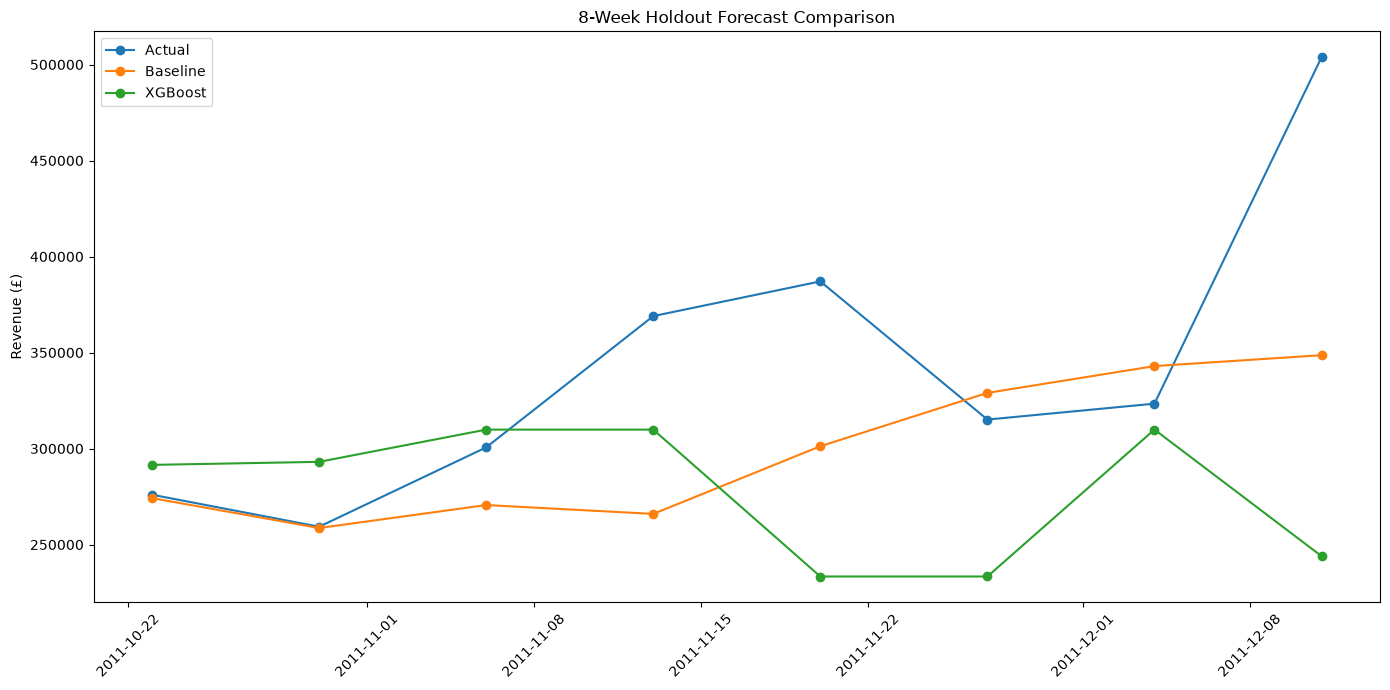

In [113]:
plt.figure(figsize=(14, 7))

plt.plot(
    forecast_df["Date"],
    forecast_df["Actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Baseline"],
    marker="o",
    label="Baseline"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xticks(rotation=45)

plt.title("8-Week Holdout Forecast Comparison")

plt.ylabel("Revenue (£)")

plt.legend()

plt.tight_layout()

plt.show()

## XGBoost feature importance

In [116]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

importance

,Feature,Importance
4,Trend,0.272273
12,RollingMean_8,0.191589
0,WeekOfYear,0.178661
9,lag_8,0.105344
8,lag_4,0.058510
13,RollingMean_12,0.046994
6,lag_2,0.045855
5,lag_1,0.030736
7,lag_3,0.022978
10,lag_12,0.021283


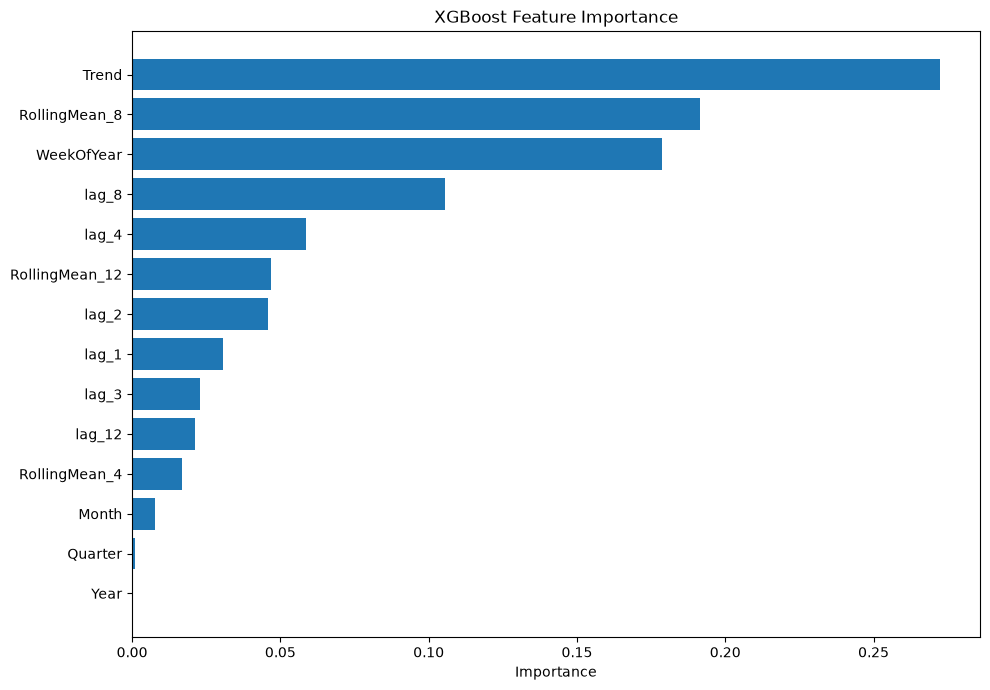

In [117]:
top_features = importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Walk-forward validation

In [119]:
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for fold, (
    train_idx,
    validation_idx
) in enumerate(
    tscv.split(weekly_model),
    start=1
):
    train_fold = weekly_model.iloc[train_idx]
    validation_fold = weekly_model.iloc[validation_idx]

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

model.fit(
    train_fold[features],
    train_fold["Revenue"]
)

prediction = model.predict(validation_fold[features])

cv_results.append({
    "Fold": fold,
    "MAE": mean_absolute_error(
        validation_fold["Revenue"],
        prediction
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            validation_fold["Revenue"],
            prediction
        )
    ),
    "MAPE": mean_absolute_percentage_error(
        validation_fold["Revenue"],
        prediction
    )
})

cv_results = pd.DataFrame(cv_results)

cv_results

,Fold,MAE,RMSE,MAPE
0,5,87456.881518,120243.722316,0.217697


## SHAP explainability

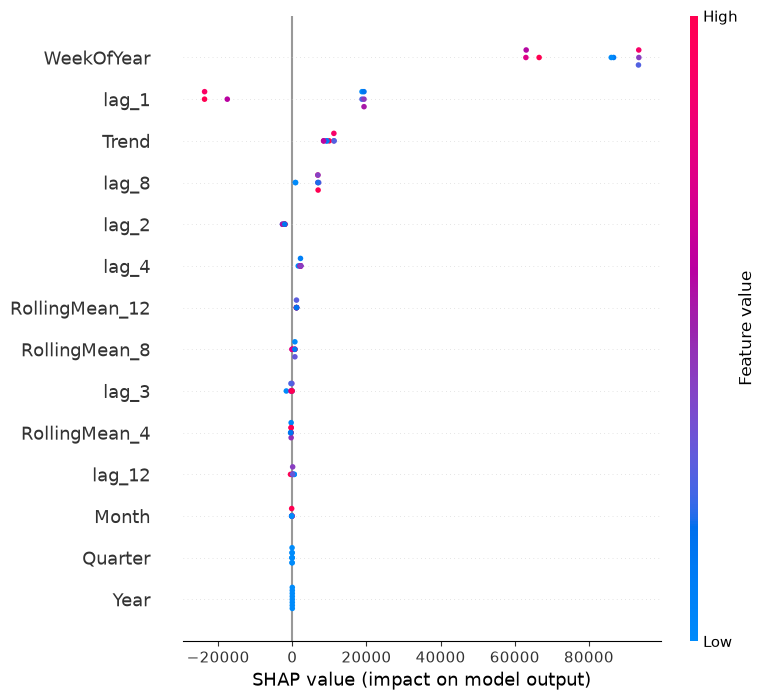

In [121]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

## Prophet benchmark

In [123]:
from prophet import Prophet

prophet_train = (train.reset_index()[["InvoiceDate", "Revenue"]])

prophet_train.columns = ["ds", "y"]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
12:23:35 - cmdstanpy - INFO - Chain [1] start processing
12:23:37 - cmdstanpy - INFO - Chain [1] done processing


In [125]:
### Generate Forecasts:

future = prophet_model.make_future_dataframe(periods=8, freq="W")

prophet_forecast = prophet_model.predict(future)

prophet_test = prophet_forecast[["ds", "yhat"]].tail(8).reset_index(drop=True)

prophet_test

,ds,yhat
0,2011-10-23,-5.165177e+05
1,2011-10-30,-2.766209e+06
2,2011-11-06,-6.607320e+06
3,2011-11-13,-1.062562e+07
4,2011-11-20,-1.227291e+07
5,2011-11-27,-9.587099e+06
6,2011-12-04,-3.041266e+06
7,2011-12-11,4.198282e+06


In [126]:
### Evaluate:

prophet_mape = (
    mean_absolute_percentage_error(
        y_test.values,
        prophet_test["yhat"].values
    )
)

print("Prophet MAPE:", prophet_mape)

Prophet MAPE: 18.647766248749413


# WEEK 5 - IMPACTFUL EVALUATION

## Baseline vs XGBoost

In [127]:
actual = y_test.values

baseline = baseline_predictions

advanced = xgb_predictions

baseline_ape = np.abs(actual - baseline) / actual

advanced_ape = np.abs(actual - advanced) / actual

baseline_mape = baseline_ape.mean()

advanced_mape = advanced_ape.mean()

print("Baseline MAPE:", baseline_mape)

print("XGBoost MAPE:", advanced_mape)

Baseline MAPE: 0.1277852513655931
XGBoost MAPE: 0.19891506454639932


## Calculate improvement

In [128]:
forecast_improvement = (baseline_mape - advanced_mape) / baseline_mape

print(
    f"Relative forecast improvement:"
    f"{forecast_improvement:.2%}"
)

Relative forecast improvement:-55.66%


## Paired statistical test

In [129]:
t_statistic, p_value = (
    stats.ttest_rel(
        baseline_ape,
        advanced_ape
    )
)

print("t-statistic:", t_statistic)

print("p-value", p_value)

t-statistic: -1.5508008134448938
p-value 0.16488583800642662


## Wilcoxon test

In [130]:
wilcoxon_stat, wilcoxon_p = (
    stats.wilcoxon(
        baseline_ape,
        advanced_ape
    )
)

print("Wilcoxon statistic:", wilcoxon_stat)

print("Wilcoxon p-value:", wilcoxon_p)

Wilcoxon statistic: 8.0
Wilcoxon p-value: 0.1953125


## Bootstrap confidence interval

In [132]:
rng = np.random.default_rng(42)

difference = baseline_ape - advanced_ape

bootstrap_means = []

for i in range(5000):

    sample = rng.choice(
        difference,
        size=len(difference),
        replace=True
    )

    bootstrap_means.append(sample.mean())

ci_low, ci_high = np.percentile(bootstrap_means, [2.5, 97.5])

print("95% CI lower:", ci_low)

print("95% CI upper:", ci_high)

95% CI lower: -0.15204925757013346
95% CI upper: 0.01394084457197603


## Week 5 evaluation table

In [133]:
impact_evaluation = pd.DataFrame({
    "Metric": [
        "Baseline MAPE",
        "XGBoost MAPE",
        "Relative Improvement",
        "Paired t-test p-value",
        "Wilcoxon p-value",
        "Bootstrap CI Lower",
        "Bootstrap CI Upper"
    ],

    "Value": [
        baseline_mape,
        advanced_mape,
        forecast_improvement,
        p_value,
        wilcoxon_p,
        ci_low,
        ci_high
    ]
})

impact_evaluation

,Metric,Value
0,Baseline MAPE,0.127785
1,XGBoost MAPE,0.198915
2,Relative Improvement,-0.556636
3,Paired t-test p-value,0.164886
4,Wilcoxon p-value,0.195312
5,Bootstrap CI Lower,-0.152049
6,Bootstrap CI Upper,0.013941


# WEEK 5 PRESPECTIVE ANALYSIS

## Create product scenario

In [134]:
recent_date = (
    sales["InvoiceDate"].max()
    - pd.Timedelta(days=56)
)

product_scenario = (
    sales[
        sales["InvoiceDate"]
        >= recent_date
    ]
    .groupby(
        [
            "StockCode",
            "Description"
        ],
        as_index=False
    )
    .agg(
        Revenue = ("Revenue", "sum"),
        Units = ("Quantity", "sum"),
        Orders = ("InvoiceNo", "nunique")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(15)
    .copy()
)

product_scenario

,StockCode,Description,Revenue,Units,Orders
2235,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3175,DOT,DOTCOM POSTAGE,68436.68,88,88
1674,23084,RABBIT NIGHT LIGHT,55655.30,25164,678
797,22086,PAPER CHAIN KIT 50'S CHRISTMAS,40986.55,11689,633
1079,22423,REGENCY CAKESTAND 3 TIER,26138.40,2022,350
891,22197,POPCORN HOLDER,23038.35,23059,387
3176,M,Manual,21366.04,5635,69
2818,85123A,WHITE HANGING HEART T-LIGHT HOLDER,18810.94,6590,399
1932,23355,HOT WATER BOTTLE KEEP CALM,18617.11,3641,485
1509,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,18033.31,5487,446


In [139]:
product_scenario [
    "Assumed_Margin_Rate"
] = np.linspace(
    0.20,
    0.40,
    len(product_scenario)
)

product_scenario[
    "Average_Price"
] = (
    product_scenario["Revenue"]
    /
    product_scenario["Units"]
    .replace(0, np.nan)
)

product_scenario[
    "Contribution_Per_Unit"
] = (
    product_scenario["Average_Price"]
    *
    product_scenario["Assumed_Margin_Rate"]
)

product_scenario

,StockCode,Description,Revenue,Units,Orders,Assumed_Margin_Rate,Average_Price,Contribution_Per_Unit
2235,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,0.200000,2.080000,0.416000
3175,DOT,DOTCOM POSTAGE,68436.68,88,88,0.214286,777.689545,166.647760
1674,23084,RABBIT NIGHT LIGHT,55655.30,25164,678,0.228571,2.211703,0.505532
797,22086,PAPER CHAIN KIT 50'S CHRISTMAS,40986.55,11689,633,0.242857,3.506421,0.851559
1079,22423,REGENCY CAKESTAND 3 TIER,26138.40,2022,350,0.257143,12.927003,3.324086
891,22197,POPCORN HOLDER,23038.35,23059,387,0.271429,0.999104,0.271185
3176,M,Manual,21366.04,5635,69,0.285714,3.791666,1.083333
2818,85123A,WHITE HANGING HEART T-LIGHT HOLDER,18810.94,6590,399,0.300000,2.854467,0.856340
1932,23355,HOT WATER BOTTLE KEEP CALM,18617.11,3641,485,0.314286,5.113186,1.607001
1509,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,18033.31,5487,446,0.328571,3.286552,1.079867


## SciPy optimization

In [141]:
capacity = int(
    product_scenario["Units"].sum() * 0.25
)

print("Scenario capacity:", capacity)

Scenario capacity: 46705


In [143]:
objective = -(
    product_scenario[
        "Contribution_Per_Unit"
        ]
        .values
)

bounds = [(0, units) for units in product_scenario["Units"]]

A_ub = np.ones((1, len(product_scenario)))

b_ub = capacity

result = linprog(
    objective,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=bounds,
    method="highs"
)

print("Optimization successful:", result.success)

Optimization successful: True


## Optimization recommendation

In [144]:
product_scenario[
    "Recommended_Allocation"
] = result.x

product_scenario[
    "Expected_Contribution"
] = (
    product_scenario[
        "Recommended_Allocation"
    ]
    *
    product_scenario[
        "Contribution_Per_Unit"
    ]
)

product_scenario[
    [
        "StockCode",
        "Description",
        "Units",
        "Assumed_Margin_Rate",
        "Recommended_Allocation",
        "Expected_Contribution"
    ]
]

,StockCode,Description,Units,Assumed_Margin_Rate,Recommended_Allocation,Expected_Contribution
2235,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,0.200000,0.0,0.000000
3175,DOT,DOTCOM POSTAGE,88,0.214286,88.0,14665.002857
1674,23084,RABBIT NIGHT LIGHT,25164,0.228571,0.0,0.000000
797,22086,PAPER CHAIN KIT 50'S CHRISTMAS,11689,0.242857,9619.0,8191.148718
1079,22423,REGENCY CAKESTAND 3 TIER,2022,0.257143,2022.0,6721.302857
891,22197,POPCORN HOLDER,23059,0.271429,0.0,0.000000
3176,M,Manual,5635,0.285714,5635.0,6104.582857
2818,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6590,0.300000,6590.0,5643.282000
1932,23355,HOT WATER BOTTLE KEEP CALM,3641,0.314286,3641.0,5851.091714
1509,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,5487,0.328571,5487.0,5925.230429


In [150]:
sales = sales.loc[:, ~sales.columns.duplicated()].copy()

print("Columns after removing duplicates:")
print(sales.columns.tolist())

Columns after removing duplicates:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'IsCancellation', 'CustomerID_was_missing', 'Price_Outlier', 'DayofWeek', 'DayOfWeek']


In [152]:
columns_to_remove = [
    col for col in sales.columns
    if col.lower() == "dayofweek"
]

sales = sales.drop(
    columns=columns_to_remove,
    errors="ignore"
)

sales["DayOfWeek"] = (
    pd.to_datetime(sales["InvoiceDate"])
    .dt.day_name()
)

print(sales.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'IsCancellation', 'CustomerID_was_missing', 'Price_Outlier', 'DayOfWeek']


# SQLAlchemy

In [153]:
from sqlalchemy import create_engine, text

engine = create_engine("sqlite:///online_retail.db")

sales.to_sql(
    "sales",
    engine,
    if_exists="replace",
    index=False
)

print("Database created successfully.")

Database created successfully.


In [154]:
query = text ("""
SELECT
    Country,
    ROUND(SUM(Revenue), 2) AS Revenue,
    COUNT(DISTINCT InvoiceNo) AS Orders
FROM sales
GROUP BY Country
ORDER BY Revenue DESC
LIMIT 10
""")

with engine.connect() as connection:
    sql_result = pd.read_sql(query, connection)

sql_result

,Country,Revenue,Orders
0,United Kingdom,9001744.09,18019
1,Netherlands,285446.34,94
2,EIRE,283140.52,288
3,Germany,228678.40,457
4,France,209625.37,392
5,Australia,138453.81,57
6,Spain,61558.56,90
7,Switzerland,57067.60,54
8,Belgium,41196.34,98
9,Sweden,38367.83,36


## Pandera - data quality validation

In [155]:
import pandera.pandas as pa

In [165]:
import pandera.pandas as pa

schema = pa.DataFrameSchema({

    "InvoiceNo": pa.Column(
        pa.String,
        nullable=False
    ),

    "StockCode": pa.Column(
        pa.String,
        nullable=False
    ),

    "Description": pa.Column(
        pa.String,
        nullable=False
    ),

    "Quantity": pa.Column(
        int,
        nullable=False
    ),

    "UnitPrice": pa.Column(
        float,
        checks=pa.Check.gt(0),
        nullable=False
    ),

    "CustomerID": pa.Column(
        pa.String,
        nullable=False
    ),

    "Country": pa.Column(
        pa.String,
        nullable=False
    ),

    "Revenue": pa.Column(
        float,
        nullable=False
    )
})

In [166]:
validated_sales = schema.validate(
    sales,
    lazy =True
)

print(f"Validation passed for "
     f"{len(validated_sales):,} rows."
)

Validation passed for 524,878 rows.


In [169]:
os.makedirs(
    "outputs/week1",
    exist_ok=True
)

os.makedirs(
    "outputs/week2",
    exist_ok=True
)

os.makedirs(
    "outputs/week3",
    exist_ok=True
)

os.makedirs(
    "outputs/week4",
    exist_ok=True
)

os.makedirs(
    "outputs/week5",
    exist_ok=True
)

In [170]:
week1_kpis.to_csv(
    "outputs/week1/strategic_kpis.csv",
    index=False
)

quality_summary.to_csv(
    "outputs/week2/quality_summary.csv",
    index=False
)

eda_kpis.to_csv(
    "outputs/week3/eda_kpis.csv",
    index=False
)

model_comparison.to_csv(
    "outputs/week4/model_comparison.csv",
    index=False
)

forecast_df.to_csv(
    "outputs/week4/forecast_predictions.csv",
    index=False
)

impact_evaluation.to_csv(
    "outputs/week5/impact_evaluation.csv",
    index=False
)

product_scenario.to_csv(
    "outputs/week5/optimization_results.csv",
    index=False
)

print(
    "All major evidence files saved."
)

All major evidence files saved.
